In [1]:
from datasets import load_dataset
from tqdm import tqdm

filename = "./base/russian_wikipedia.txt"

ds = load_dataset(
    "wikimedia/wikipedia",
    "20231101.ru",
    split="train",
    streaming=True
)

for item in ds:
    print(item["text"][:500])
    break

with open(filename, "w", encoding="utf-8") as f:
    for i, item in enumerate(tqdm(ds)):
        if i >= 10000:
            break
        f.write(item["text"] + "\n")


c:\Users\Миша\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Литва́ ( ), официальное название — Лито́вская Респу́блика () — государство, расположенное в Северной Европе. Площадь —  км². Протяжённость с севера на юг — 280 км, а с запада на восток — 370 км. Население составляет  человек (август, 2023). Занимает 137-е место в мире по численности населения и 121-е по территории. Имеет выход к Балтийскому морю, расположена на его восточном побережье. Береговая линия составляет всего 99 км (наименьший показатель среди государств Балтии). На севере граничит с Ла


10000it [00:21, 475.13it/s]


In [12]:
from os import walk
import re
from tqdm import tqdm

base_path = './base/'
# base_path = './skazka/'

data_text = ''

for dirpath, dirnames, filenames in walk(base_path):
    for file_name in filenames:
        if file_name[-4:] != '.txt': continue

        print('Read:', file_name)
        try:
            current_text = open(dirpath + '/' + file_name, 'r', encoding='utf-8').read()
            data_text += current_text
        except Exception as e:
            print(f'Error reading {file_name}: {e}')

import pymorphy3

morph = pymorphy3.MorphAnalyzer()

_lemma_cache = {}

def lemmatize(text, show_progress=False):
    words = text.strip().split()
    
    cache = _lemma_cache
    parse = morph.parse
    lemmatized_words = []
    append = lemmatized_words.append
    
    iterator = tqdm(words, disable=not show_progress)
        
    for word in iterator:
        if word not in cache:
            cache[word] = parse(word)[0].normal_form
        append(cache[word])
        
    return ' '.join(lemmatized_words)

def prepare_text(text):
    n_text = text.lower()
    n_text = re.sub(r'[^а-яё\s]+', ' ', n_text)
    n_text = re.sub(r'ё', 'е', n_text)
    n_text = re.sub(r'\n+', ' ', n_text)
    n_text = re.sub(r'\s+', ' ', n_text)

    return n_text

data_text = prepare_text(data_text)
# data_text = lemmatize(data_text, show_progress=True)

alphabet = list(set(data_text))

print('---')
print('Final data length:', len(data_text), 'symbols')
print('Alphabet length:', len(alphabet))
print('Alphabet:', alphabet)
print('Text sample:', data_text[:100])

Read: russian_wikipedia.txt
---
Final data length: 110594518 symbols
Alphabet length: 33
Alphabet: ['ъ', 'у', 'ш', 'ц', 'г', 'м', 'з', 'л', 'е', 'к', 'ж', 'о', 'ф', 'а', 'э', 'щ', 'н', 'х', 'ы', 'р', 'б', 'ю', 'т', 'ь', ' ', 'й', 'в', 'п', 'и', 'с', 'д', 'я', 'ч']
Text sample: литва официальное название лито вская респу блика государство расположенное в северной европе площад


In [13]:
from collections import defaultdict, Counter
from typing import List, Dict, Set

words = data_text.split()
freq = Counter(words)

min_frequency = 10

CLEAR_MEMORY = True

vocab = {w for w, c in freq.items() if c >= min_frequency}

print('words in data:', len(words))
print(f"Before word count: {len(freq)}")
print(f"Vocabulary size: {len(vocab)}")

words in data: 14918719
Before word count: 592172
Vocabulary size: 100484


In [14]:
from tqdm import tqdm
import gc

word_to_id = {w: i for i, w in enumerate(sorted(vocab))}
# id_to_word = {i: w for w, i in word_to_id.items()}

context_to_words: Dict[int, Set[int]] = defaultdict(set)
# context_to_context: Dict[int, Set[int]] = defaultdict(set)

radius = 2

for i, w in enumerate(tqdm(words)):
    if i < radius or i >= len(words) - radius:
        continue
    if w not in vocab:
        continue

    w_id = word_to_id[w]
    left = max(0, i - radius)
    right = min(len(words), i + radius + 1)

    context_word_ids = set()
    for j in range(left, right):
        if j == i:
            continue
        cand = words[j]
        if cand in vocab:
            context_word_ids.add(word_to_id[cand])

    if not context_word_ids:
        continue

    ctx_key = frozenset(context_word_ids)
    ctx_id = hash(ctx_key)

    context_to_words[ctx_id].add(w_id)
    # context_to_context[ctx_id] = context_word_ids

print(f"Total contexts: {len(context_to_words)}")

if CLEAR_MEMORY:
    del words
    gc.collect()

100%|██████████| 14918719/14918719 [01:18<00:00, 190320.95it/s]


Total contexts: 12749346


Mean number of contexts per word: 131.32
Standard deviation of contexts per word: 2803.68
131.32 ± 2803.68


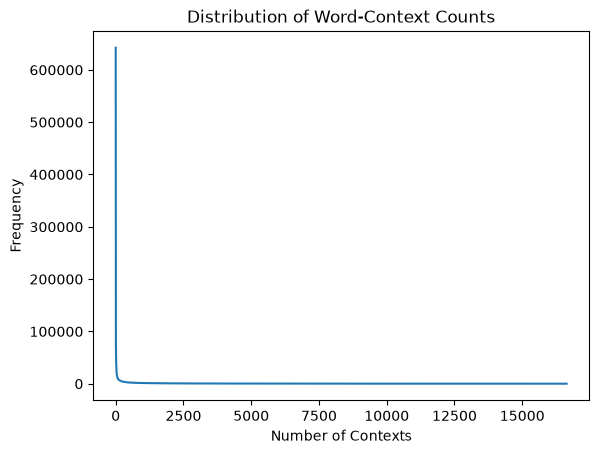

In [15]:
import matplotlib.pyplot as plt

# количество контекстов для каждого слова
word_context_counts = dict()
for ctx_id, word_ids in context_to_words.items():
    for w_id in word_ids:
        word_context_counts[w_id] = word_context_counts.get(w_id, 0) + 1

word_context_counts = sorted(word_context_counts.items(), key=lambda x: x[1], reverse=True)

mean_contexts = sum(count for word, count in word_context_counts) / len(word_context_counts)
print(f"Mean number of contexts per word: {mean_contexts:.2f}")

std_contexts = (sum((count - mean_contexts) ** 2 for word, count in word_context_counts) / len(word_context_counts)) ** 0.5
print(f"Standard deviation of contexts per word: {std_contexts:.2f}")

print(f"{mean_contexts:.2f} ± {std_contexts:.2f}")

plt.plot([count for word, count in word_context_counts if count > 100])
plt.xlabel('Number of Contexts')
plt.ylabel('Frequency')
plt.title('Distribution of Word-Context Counts')
plt.show()

if CLEAR_MEMORY:
    del word_context_counts
    gc.collect()

Mean number of words per context: 1.03
Standard deviation of words per context: 1.35
1.03 ± 1.35


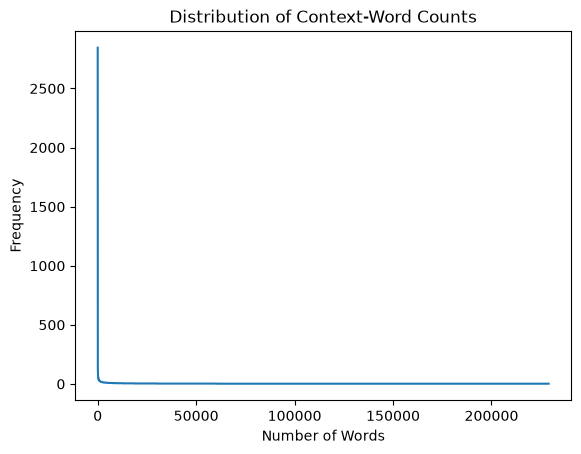

In [16]:
# количество слов для каждого контекста

context_word_counts = {ctx_id: len(word_ids) for ctx_id, word_ids in context_to_words.items()}

context_word_counts = sorted(context_word_counts.items(), key=lambda x: x[1], reverse=True)

mean_words = sum(count for ctx, count in context_word_counts) / len(context_word_counts)
print(f"Mean number of words per context: {mean_words:.2f}")

std_words = (sum((count - mean_words) ** 2 for ctx, count in context_word_counts) / len(context_word_counts)) ** 0.5
print(f"Standard deviation of words per context: {std_words:.2f}")

print(f"{mean_words:.2f} ± {std_words:.2f}")

plt.plot([count for ctx, count in context_word_counts if count > 1])
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Context-Word Counts')
plt.show()

if CLEAR_MEMORY:
    del context_word_counts
    gc.collect()

In [17]:
blocked: Dict[int, Set[int]] = defaultdict(set)

for ctx_id, ctx_words in tqdm(context_to_words.items()):
    ctx_words_list = list(ctx_words)
    for a in ctx_words_list:
        for b in ctx_words_list:
            if a != b:
                blocked[a].add(b)

if CLEAR_MEMORY:
    del context_to_words
    gc.collect()

class_members: List[Set[int]] = []
word_to_class: Dict[str, int] = {}

sorted_words = sorted(vocab, key=lambda x: (freq[x], x))

for w in tqdm(sorted_words):
    w_id = word_to_id[w]

    placed = False
    for class_id, members in enumerate(class_members):
        if not (blocked[w_id] & members):
            members.add(w_id)
            word_to_class[w] = class_id
            placed = True
            break

    if not placed:
        class_members.append({w_id})
        word_to_class[w] = len(class_members) - 1

classes: Dict[int, List[str]] = {}
for w, cls in word_to_class.items():
    classes.setdefault(cls, []).append(w)

for cls in classes:
    classes[cls].sort()

100%|██████████| 100484/100484 [00:09<00:00, 11159.70it/s]


In [18]:
print('classes:', len(classes))

print(', '.join(str(len(words)) for words in classes.values()))

for cls_id, words_in_class in classes.items():
    print(f"Class {cls_id}: {len(words_in_class)} words")
    print(words_in_class[:20]) 
    print('---')

classes: 2845
56797, 10247, 4587, 2755, 1961, 1437, 1166, 950, 802, 703, 623, 529, 482, 438, 380, 358, 321, 299, 282, 262, 246, 234, 214, 202, 184, 186, 171, 171, 166, 157, 140, 137, 131, 129, 123, 119, 119, 116, 105, 102, 102, 99, 91, 83, 85, 83, 84, 79, 83, 75, 71, 69, 66, 65, 62, 61, 64, 62, 63, 59, 58, 58, 53, 54, 52, 51, 53, 50, 49, 48, 49, 46, 48, 43, 43, 44, 41, 45, 43, 43, 42, 40, 37, 39, 40, 35, 35, 37, 38, 37, 35, 32, 32, 33, 33, 32, 33, 34, 33, 33, 30, 29, 29, 27, 27, 26, 28, 26, 27, 26, 26, 26, 27, 24, 24, 23, 24, 25, 21, 25, 23, 22, 23, 25, 24, 24, 22, 25, 23, 23, 22, 22, 21, 21, 21, 20, 22, 22, 23, 19, 21, 21, 22, 22, 22, 18, 21, 19, 19, 21, 20, 19, 19, 19, 20, 19, 18, 18, 16, 17, 16, 17, 15, 15, 16, 15, 15, 15, 15, 14, 15, 12, 13, 14, 15, 15, 15, 13, 15, 15, 14, 15, 15, 13, 15, 15, 15, 12, 15, 13, 14, 14, 13, 13, 12, 13, 13, 13, 13, 12, 13, 13, 12, 12, 13, 12, 13, 13, 13, 11, 11, 13, 12, 12, 12, 12, 12, 11, 13, 12, 13, 13, 12, 11, 13, 12, 13, 13, 13, 12, 11, 12, 13, 11, 

In [19]:
def encode_sentence_to_classes(sentence: str, word_to_class: dict) -> list[int | None]:
    tokens = sentence.lower().split()
    result = []

    for token in tokens:
        cls_id = word_to_class.get(token)
        result.append(cls_id)

    return result

sample_sentence = "результат сжатия текста с использованием классов омонимов"
encoded = encode_sentence_to_classes(sample_sentence, word_to_class)

print("Sentence:", sample_sentence)
print("Encoded:", encoded)

sample_sentence = "замок лук"
encoded = encode_sentence_to_classes(sample_sentence, word_to_class)

print("Sentence:", sample_sentence)
print("Encoded:", encoded)

Sentence: результат сжатия текста с использованием классов омонимов
Encoded: [21, 8, 2396, 2841, 2403, 19, 0]
Sentence: замок лук
Encoded: [900, 4]
